In [122]:
import numpy as np

In [123]:
x = np.random.multivariate_normal( mean=[0,0],
                                  cov=[[1,0],[0,1]],
                                 size = 1000)

In [124]:
y = np.random.multivariate_normal( mean=[0,0],
                                  cov=[[1,0.8],[0.8,1]],
                                 size = 1000)

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

<Axes: >

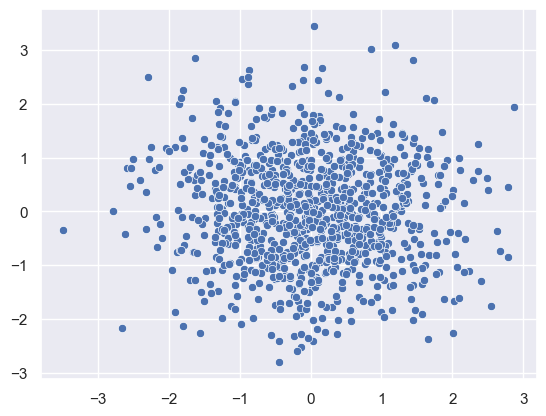

In [126]:
# plt indep Gaussian
sns.scatterplot(x=x[:,0],y=x[:,1])

<Axes: >

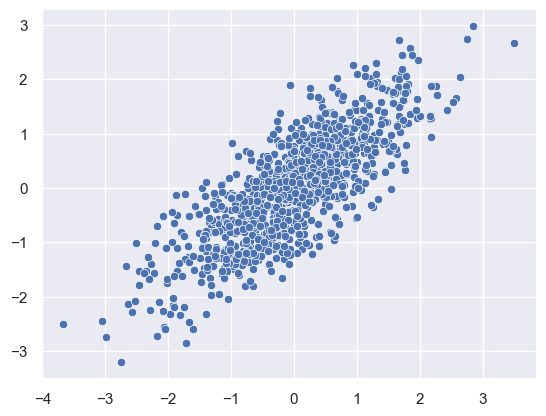

In [127]:
# plt cor Gaussian
sns.scatterplot(x=y[:,0],y=y[:,1])

# Define MINE

In [128]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [129]:
class Mine(nn.Module):
    def __init__(self, input_size=2, hidden_size=20):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        nn.init.normal_(self.fc1.weight,std=0.02)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight,std=0.02)
        nn.init.constant_(self.fc2.bias, 0)
        nn.init.normal_(self.fc3.weight,std=0.02)
        nn.init.constant_(self.fc3.bias, 0)
        
    def forward(self, input):
        output = F.elu(self.fc1(input))
        output = F.elu(self.fc2(output))
        output = self.fc3(output)
        return output

In [130]:
def logmeanexp(x):
    max_x = torch.max(x)
    return max_x + torch.log(torch.mean(torch.exp(x - max_x)) + 1e-8)


def mutual_information(joint, marginal, mine_net):
    t_joint = mine_net(joint)
    t_marginal = mine_net(marginal)

    mi_lb = torch.mean(t_joint) - logmeanexp(t_marginal)
    return mi_lb, t_joint, t_marginal


def learn_mine(batch, mine_net, mine_net_optim, ma_et, ma_rate=0.01):
    joint, marginal = batch

    joint = torch.FloatTensor(joint)
    marginal = torch.FloatTensor(marginal)

    mi_lb, t_joint, t_marg = mutual_information(joint, marginal, mine_net)

    et = torch.exp(t_marg)

    with torch.no_grad():
        ma_et = (1 - ma_rate) * ma_et + ma_rate * torch.mean(et)

    loss = -(torch.mean(t_joint) - (torch.mean(et) / ma_et.detach()))

    mine_net_optim.zero_grad()
    loss.backward()
    mine_net_optim.step()

    return mi_lb.detach(), ma_et


In [131]:
def sample_batch(data, batch_size=100, sample_mode='joint'):
    if sample_mode == 'joint':
        index = np.random.choice(range(data.shape[0]), size=batch_size, replace=False)
        batch = data[index]
    else:
        joint_index = np.random.choice(range(data.shape[0]), size=batch_size, replace=False)
        marginal_index = np.random.choice(range(data.shape[0]), size=batch_size, replace=False)
        batch = np.concatenate([data[joint_index][:,0].reshape(-1,1),
                                         data[marginal_index][:,1].reshape(-1,1)],
                                       axis=1)
    return batch

<Axes: >

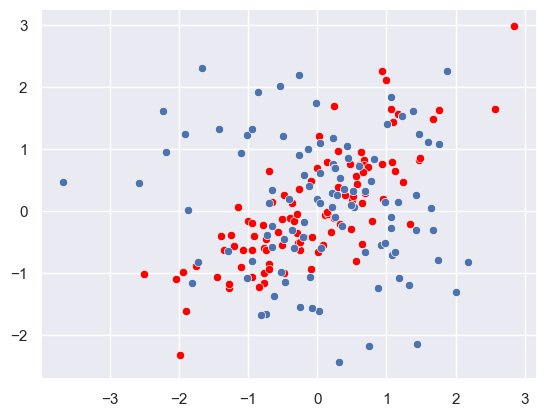

In [132]:
joint_data = sample_batch(y,batch_size=100,sample_mode='joint')
sns.scatterplot(x=joint_data[:,0],y=joint_data[:,1],color='red')
marginal_data = sample_batch(y,batch_size=100,sample_mode='marginal')
sns.scatterplot(x=marginal_data[:,0],y=marginal_data[:,1])

In [133]:
def train(data, mine_net,mine_net_optim, batch_size=100, iter_num=int(5e+3), log_freq=int(1e+3)):
    result = list()
    ma_et = 0
    for i in range(iter_num):
        batch = sample_batch(data,batch_size=batch_size)\
        , sample_batch(data,batch_size=batch_size,sample_mode='marginal')
        mi_lb, ma_et = learn_mine(batch, mine_net, mine_net_optim, ma_et)
        result.append(mi_lb.detach().cpu().numpy())
        if (i+1)%(log_freq)==0:
            print(result[-1])
    return result

In [134]:
def ma(a, window_size=100):
    return [np.mean(a[i:i+window_size]) for i in range(0,len(a)-window_size)]

In [156]:
mine_net_indep = Mine()
mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr=1e-3)
result_indep = train(x,mine_net_indep,mine_net_optim_indep)

-0.00020986795
-0.00023663044
-0.0041617155
-0.000782907
-0.0022135377


6.135523e-05


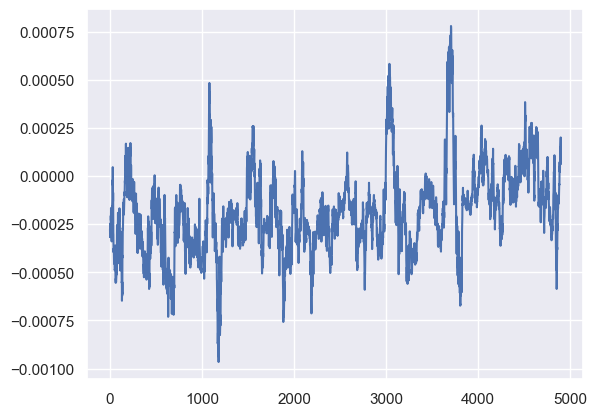

In [157]:
result_indep_ma = ma(result_indep)
print(result_indep_ma[-1])
plt.plot(range(len(result_indep_ma)),result_indep_ma)

In [ ]:
mine_net_cor = Mine()
mine_net_optim_cor = optim.Adam(mine_net_cor.parameters(), lr=1e-3)
result_cor = train(y,mine_net_cor,mine_net_optim_cor)

0.1371789
0.66734827
0.7237308
0.47268808
0.5509444


0.53024364


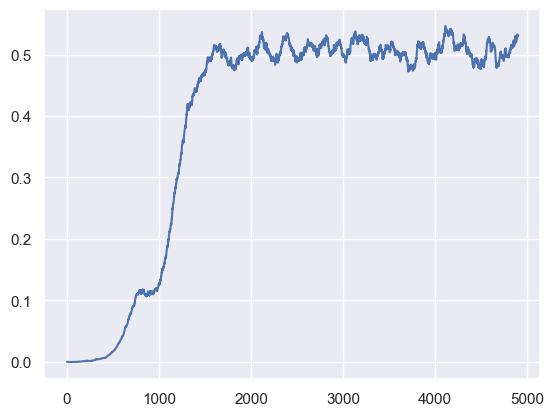

In [ ]:
result_cor_ma = ma(result_cor)
print(result_cor_ma[-1])
plt.plot(range(len(result_cor_ma)),result_cor_ma)

# Test with various correlations

In [139]:
correlations = np.linspace(-0.9,0.9,19)
print(correlations)

[-0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4
  0.5  0.6  0.7  0.8  0.9]


0.561166
0.8043462
0.65195936
0.727687
0.90675014
-0.9 : 0.74160284
0.28862292
0.56378776
0.5499003
0.66086775
0.58862704
-0.8 : 0.56298065
0.27162445
0.22950226
0.41975826
0.38352785
0.3376303
-0.7 : 0.33285514
0.13137943
0.09242982
0.2060416
0.16050142
0.17675057
-0.6 : 0.24809973
0.0029869676
0.00742352
0.07539302
0.16499978
0.021419942
-0.5 : 0.12781098
0.007836521
0.021999598
0.00740391
0.042173564
0.018520296
-0.4 : 0.017910564
0.0020537376
0.027883947
0.014482617
0.05470985
0.08914924
-0.29999999999999993 : 0.084597185
-0.0027496815
0.011557281
0.026969373
0.00563401
-0.008588672
-0.19999999999999996 : 0.0064339163
0.00068861246
0.00017517805
0.0051000714
-0.0025918484
0.0060017705
-0.09999999999999998 : 0.003001148
0.005492091
0.0033099651
-0.0014508367
0.0012006164
-4.440546e-05
0.0 : -1.29711625e-05
-0.00036859512
0.0013617277
0.00021594763
-0.0011173487
0.00010877848
0.09999999999999998 : -4.98271e-05
0.0016649961
-0.015282631
0.009287238
0.010710537
0.007542491
0.2000000000

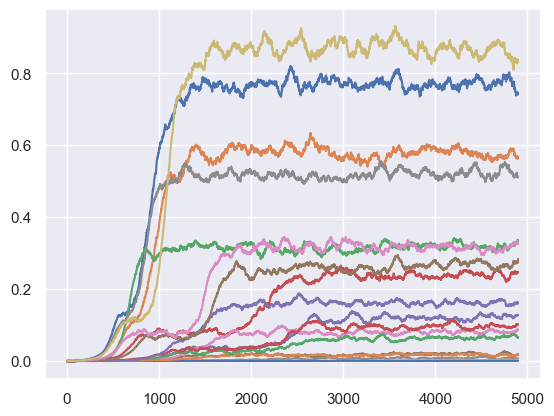

In [140]:
final_result = []
for rho in correlations:
    rho_data = np.random.multivariate_normal( mean=[0,0],
                                  cov=[[1,rho],[rho,1]],
                                 size = 300)
    mine_net = Mine()
    mine_net_optim = optim.Adam(mine_net.parameters(), lr=1e-3)
    result = train(rho_data,mine_net,mine_net_optim)
    result_ma = ma(result)
    final_result.append(result_ma[-1])
    print(str(rho) + ' : ' + str(final_result[-1]))
    plt.plot(range(len(result_ma)),result_ma)

In [141]:
rho_range = np.linspace(-0.9, 0.9, 1000)
theoretic_ma = -0.5*np.log(1-rho_range**2)

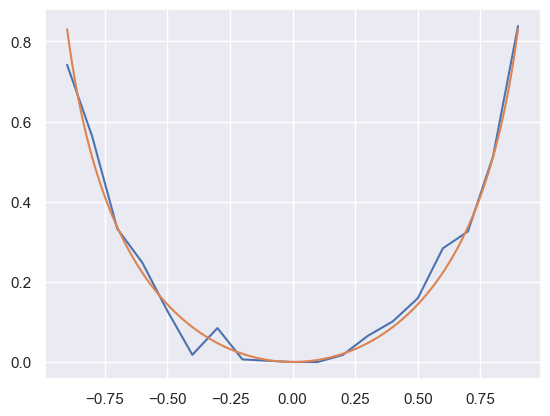

In [142]:
plt.plot(correlations, final_result)
plt.plot(rho_range, theoretic_ma)

# EXPLORATIONS

-0.008619964
-0.0056192875
0.004781306
0.008312821
-0.00453043
0.0018524778


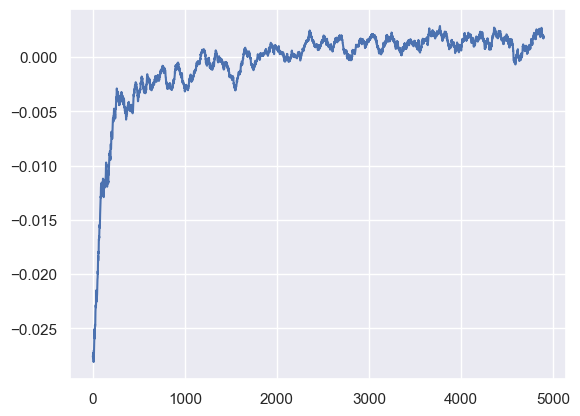

0.34265605
0.62956965
0.34094983
0.51172787
0.5269923
0.4965397


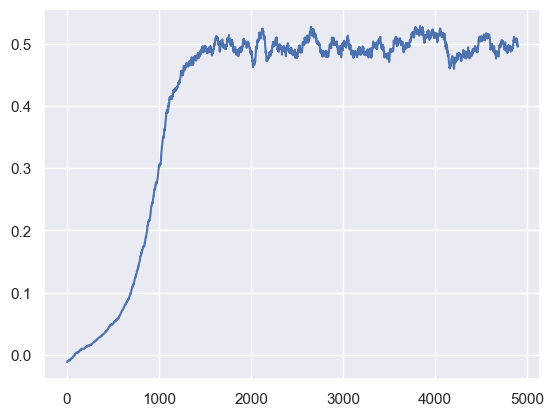

In [160]:
class Mine2(nn.Module):
    def __init__(self, input_size=2, hidden_size=20):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        
    def forward(self, input):
        output = F.elu(self.fc1(input))
        output = F.elu(self.fc2(output))
        output = self.fc3(output)
        return output
    
mine_net_indep = Mine2()
mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr=1e-3)
result_indep = train(x,mine_net_indep,mine_net_optim_indep)

result_indep_ma = ma(result_indep)
print(result_indep_ma[-1])
plt.figure()
plt.plot(range(len(result_indep_ma)),result_indep_ma)
plt.show()

mine_net_cor = Mine2()
mine_net_optim_cor = optim.Adam(mine_net_cor.parameters(), lr=1e-3)
result_cor = train(y,mine_net_cor,mine_net_optim_cor)

result_cor_ma = ma(result_cor)
print(result_cor_ma[-1])
plt.figure()
plt.plot(range(len(result_cor_ma)),result_cor_ma)
plt.show()

0.009305656
0.016510487
0.010528266
0.017583847
-0.0039949417
0.005456586


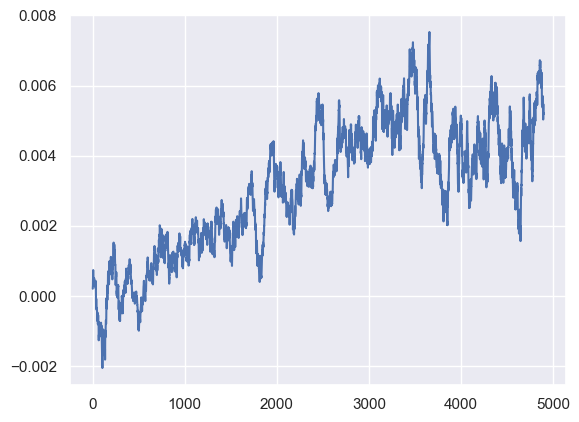

0.42419446
0.64418167
0.33491185
0.2830341
0.31352726
0.51848483


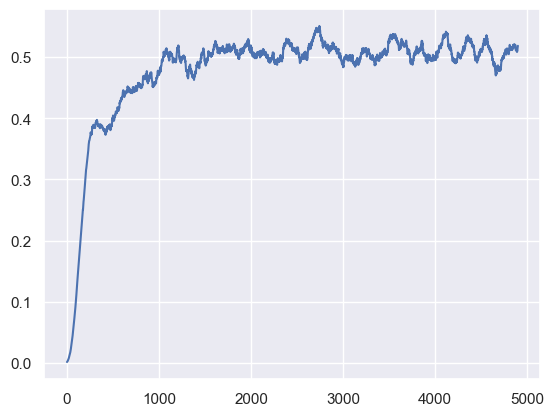

In [159]:
class Mine3(nn.Module):
    def __init__(self, input_size=2, hidden_size=20):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        nn.init.normal_(self.fc1.weight,std=0.02)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight,std=0.02)
        nn.init.constant_(self.fc2.bias, 0)
        nn.init.normal_(self.fc3.weight,std=0.02)
        nn.init.constant_(self.fc3.bias, 0)
        
    def forward(self, input):
        output = F.relu(self.fc1(input))
        output = F.relu(self.fc2(output))
        output = self.fc3(output)
        return output
    
mine_net_indep = Mine3()
mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr=1e-3)
result_indep = train(x,mine_net_indep,mine_net_optim_indep)

result_indep_ma = ma(result_indep)
print(result_indep_ma[-1])
plt.figure()
plt.plot(range(len(result_indep_ma)),result_indep_ma)
plt.show()

mine_net_cor = Mine3()
mine_net_optim_cor = optim.Adam(mine_net_cor.parameters(), lr=1e-3)
result_cor = train(y,mine_net_cor,mine_net_optim_cor)

result_cor_ma = ma(result_cor)
print(result_cor_ma[-1])
plt.figure()
plt.plot(range(len(result_cor_ma)),result_cor_ma)
plt.show()

-0.0020824075
-0.002647698
0.0045517087
0.0019326806
0.00028449297
-0.0001478082


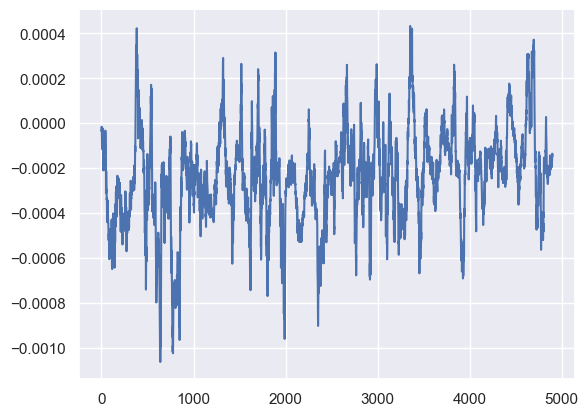

0.008287847
0.12691426
0.4187635
0.38186485
0.78581816
0.48887813


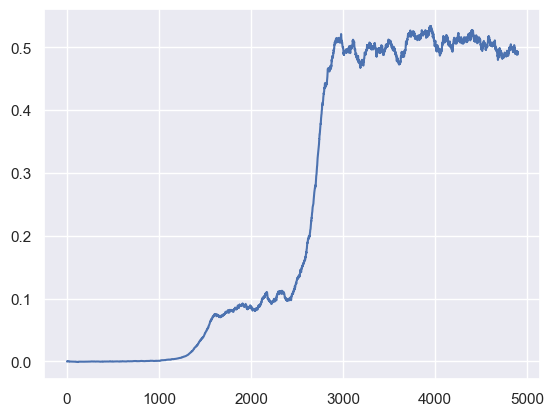

In [161]:
class Mine4(nn.Module):
    def __init__(self, input_size=2, hidden_size=20):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        nn.init.normal_(self.fc1.weight,std=0.02)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight,std=0.02)
        nn.init.constant_(self.fc2.bias, 0)
        nn.init.normal_(self.fc3.weight,std=0.02)
        nn.init.constant_(self.fc3.bias, 0)
        
    def forward(self, input):
        output = F.tanh(self.fc1(input))
        output = F.tanh(self.fc2(output))
        output = self.fc3(output)
        return output
    
mine_net_indep = Mine4()
mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr=1e-3)
result_indep = train(x,mine_net_indep,mine_net_optim_indep)

result_indep_ma = ma(result_indep)
print(result_indep_ma[-1])
plt.figure()
plt.plot(range(len(result_indep_ma)),result_indep_ma)
plt.show()

mine_net_cor = Mine4()
mine_net_optim_cor = optim.Adam(mine_net_cor.parameters(), lr=1e-3)
result_cor = train(y,mine_net_cor,mine_net_optim_cor)

result_cor_ma = ma(result_cor)
print(result_cor_ma[-1])
plt.figure()
plt.plot(range(len(result_cor_ma)),result_cor_ma)
plt.show()

2.6134265e-05
-4.6734218e-05
-1.6711128e-06
5.2829273e-06
2.0917025e-05
-1.7545838e-06


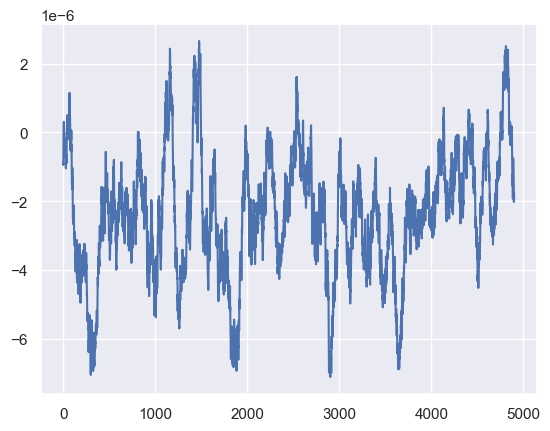

4.2368316e-05
4.266735e-05
4.727485e-05
0.00010446311
0.00011107672
0.000103827355


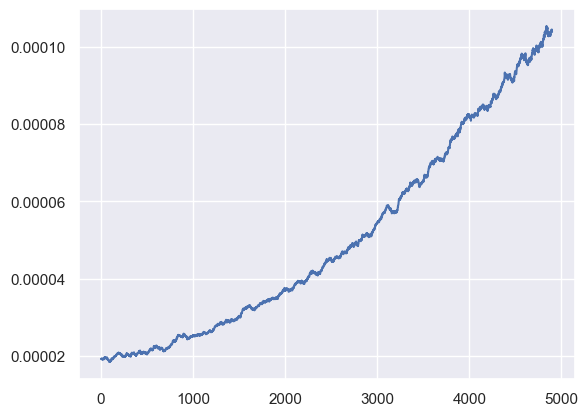

In [162]:
class Mine3(nn.Module):
    def __init__(self, input_size=2, hidden_size=20):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        nn.init.normal_(self.fc1.weight,std=0.02)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.normal_(self.fc2.weight,std=0.02)
        nn.init.constant_(self.fc2.bias, 0)
        nn.init.normal_(self.fc3.weight,std=0.02)
        nn.init.constant_(self.fc3.bias, 0)
        
    def forward(self, input):
        output = F.relu(self.fc1(input))
        output = F.relu(self.fc2(output))
        output = self.fc3(output)
        return output
    
mine_net_indep = Mine3()
mine_net_optim_indep = optim.Adam(mine_net_indep.parameters(), lr=1e-6)
result_indep = train(x,mine_net_indep,mine_net_optim_indep)

result_indep_ma = ma(result_indep)
print(result_indep_ma[-1])
plt.figure()
plt.plot(range(len(result_indep_ma)),result_indep_ma)
plt.show()

mine_net_cor = Mine3()
mine_net_optim_cor = optim.Adam(mine_net_cor.parameters(), lr=1e-6)
result_cor = train(y,mine_net_cor,mine_net_optim_cor)

result_cor_ma = ma(result_cor)
print(result_cor_ma[-1])
plt.figure()
plt.plot(range(len(result_cor_ma)),result_cor_ma)
plt.show()